# P2 · Demographic Change by Period: Pre- and Post-Inflection (2011–2024)
## *Cumulative Population Change Across Symmetric Periods A (2011–2017) and B (2018–2024)*

---

**Paper:** Rural Migration and Land Use in Spain — Paper 1  
**Step:** 2 — Period analysis  
**Author:** Juan Zotes  
**Last updated:** 2026-04

---

### Context and purpose

The inflection point T=2018 was confirmed in p1b using the estimated migratory balance
(Padrón minus MNP vegetative balance): migratory balance for municipalities <5,000 inhabitants
becomes sustainably positive in 2018, independently corroborating the MITERD (2022) finding.

This notebook defines two symmetric 7-year periods around T=2018 and computes municipal-level
demographic change indicators for each:

| Period | Years | Label |
|--------|-------|-------|
| A | 2011–2017 | Pre-inflection |
| B | 2018–2024 | Post-inflection |

### Indicators

Per municipality × period:
- **`var_acum_pct`** — cumulative % change: $(P_{end} - P_{start}) / P_{start} \times 100$
- **`var_anual_media_pct`** — mean annual growth rate (CAGR): $((P_{end}/P_{start})^{1/n} - 1) \times 100$
- **`pop_YYYY`** — year-by-year population (multi-k intra-period)

### Figures

| Figure | Content | Groups |
|--------|---------|--------|
| Fig. 1 | Cumulative % change A vs B by size group | 6 size groups |
| Fig. 2 | Cumulative % change A vs B by Goerlich typology | 6 typologies |

Each figure: combined (3×2), pairs, individual panels. EN + ES versions.  
Saved to `figures/p2_period_analysis/`.

### Inputs

| File | Location | Description |
|------|----------|-------------|
| `01_padron_clean_1996_2024.csv` | `data/demography/processed/` | Municipal population 1996–2024, long format |
| `p0_municipios_goerlich_admin_hierarchy.csv` | `data/spatial/processed/` | Municipal typology + administrative hierarchy |

In [1]:
"""
Notebook  : p2_period_analysis.ipynb
Author    : Juan Zotes
Created   : 2026-04

Purpose:
    Compute cumulative and mean annual population change for each municipality
    across two symmetric 7-year periods defined by the confirmed inflection
    point T=2018:
        Period A: 2011-2017 (pre-inflection)
        Period B: 2018-2024 (post-inflection)

    Stratified by municipality size group (2020 reference year) and
    Goerlich (2016) functional typology.

Inputs:
    - 01_padron_clean_1996_2024.csv              (demography/processed)
    - p0_municipios_goerlich_admin_hierarchy.csv (spatial/processed)

Outputs:
    Figures (figures/p2_period_analysis/):
        - p2_fig1_size_combined_{lang}.png
        - p2_fig1_size_pair_{top/mid/bot}_{lang}.png
        - p2_fig1_size_individual_{group}_{lang}.png
        - p2_fig2_typology_combined_{lang}.png
        - p2_fig2_typology_pair_{top/mid/bot}_{lang}.png
        - p2_fig2_typology_individual_{type}_{lang}.png

    Derived data (demography/derived/):
        - p2_period_A_2011_2017.csv
        - p2_period_B_2018_2024.csv
        - p2_periods_AB_combined.csv

Notes:
    - Cat == 'Total' only.
    - Size classification based on 2020 population (reference year).
    - Municipalities with pop_start == 0 or NaN: var_acum_pct and CAGR set to NaN.
    - Figures show mean var_acum_pct per stratum, A (grey) vs B (colour).
"""

"\nNotebook  : p2_period_analysis.ipynb\nAuthor    : Juan Zotes\nCreated   : 2026-04\n\nPurpose:\n    Compute cumulative and mean annual population change for each municipality\n    across two symmetric 7-year periods defined by the confirmed inflection\n    point T=2018:\n        Period A: 2011-2017 (pre-inflection)\n        Period B: 2018-2024 (post-inflection)\n\n    Stratified by municipality size group (2020 reference year) and\n    Goerlich (2016) functional typology.\n\nInputs:\n    - 01_padron_clean_1996_2024.csv              (demography/processed)\n    - p0_municipios_goerlich_admin_hierarchy.csv (spatial/processed)\n\nOutputs:\n    Figures (figures/p2_period_analysis/):\n        - p2_fig1_size_combined_{lang}.png\n        - p2_fig1_size_pair_{top/mid/bot}_{lang}.png\n        - p2_fig1_size_individual_{group}_{lang}.png\n        - p2_fig2_typology_combined_{lang}.png\n        - p2_fig2_typology_pair_{top/mid/bot}_{lang}.png\n        - p2_fig2_typology_individual_{type}_{lang}.

---
## 0 · Environment and paths

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('Libraries loaded.')

Libraries loaded.


In [2]:
# --- Paths -----------------------------------------------------------
BASE_DIR = Path(
    r'C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE'
    r'\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain'
)

DEMO_PROC    = BASE_DIR / 'data' / 'demography' / 'processed'
DEMO_DERIV   = BASE_DIR / 'data' / 'demography' / 'derived'
FIGURES_DIR  = BASE_DIR / 'figures' / 'p2_period_analysis'

DEMO_DERIV.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FP_INPUT = DEMO_PROC / 'p0_padron_goerlich_1996_2024.csv'

print('Paths defined.')
print(f"  {'OK' if FP_INPUT.exists() else 'MISSING'} -> {FP_INPUT.name}")

Paths defined.
  OK -> p0_padron_goerlich_1996_2024.csv


In [3]:
# --- Colour palettes -------------------------------------------------
GOERLICH_COLORS = {
    'Rural - Accesible'    : '#74c476',
    'Rural - Remoto'       : '#238b45',
    'Intermedio - Abierto' : '#6baed6',
    'Intermedio - Cerrado' : '#2171b5',
    'Urbano - Abierto'     : '#fd8d3c',
    'Urbano - Cerrado'     : '#bd0026',
}

TYPOLOGY_ORDER = [
    'Urbano - Cerrado',
    'Urbano - Abierto',
    'Intermedio - Cerrado',
    'Intermedio - Abierto',
    'Rural - Accesible',
    'Rural - Remoto',
]

SIZE_COLORS = {
    '> 50,000'        : '#bd0026',
    '10,000 - 50,000' : '#fd8d3c',
    '5,000 - 10,000'  : '#fecc5c',
    '< 5,000 (total)' : '#2171b5',
    '1,000 - 5,000'   : '#6baed6',
    '< 1,000'         : '#238b45',
}

SIZE_ORDER = [
    '> 50,000',
    '10,000 - 50,000',
    '5,000 - 10,000',
    '< 5,000 (total)',
    '1,000 - 5,000',
    '< 1,000',
]

COL_PERIOD_A = '#aaaaaa'   # grey — Period A (pre-inflection)
# Period B uses the stratum colour

print('Palettes defined.')

Palettes defined.


---
## 1 · Load and prepare data

In [4]:
# --- Load data (padron + Goerlich typology already integrated) -------
df = pd.read_csv(FP_INPUT, dtype={'Mun_Code': str}, sep=';', encoding='utf-8')
df['Mun_Code'] = df['Mun_Code'].str.zfill(5)
df['Pop']      = pd.to_numeric(df['Pop'], errors='coerce')
df_total       = df[df['Cat'] == 'Total'].copy()

print(f'Rows (Cat=Total): {len(df_total):,}')
print(f'Municipalities  : {df_total["Mun_Code"].nunique():,}')
print(f'Years           : {sorted(df_total["Year"].unique())}')
print(f'tipo_goerlich   : {df_total["tipo_goerlich"].value_counts().to_dict()}')

Rows (Cat=Total): 227,696
Municipalities  : 8,132
Years           : [np.int64(1996), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
tipo_goerlich   : {'Rural - Accesible': 108780, 'Rural - Remoto': 79464, 'Intermedio - Abierto': 27216, 'Intermedio - Cerrado': 5320, 'Urbano - Cerrado': 4592, 'Urbano - Abierto': 2324}


In [5]:
# --- Assign size group using 2020 population (reference year) --------
REF_YEAR = 2020

pop_ref = (
    df_total[df_total['Year'] == REF_YEAR][['Mun_Code', 'Pop']]
    .rename(columns={'Pop': 'Pop_ref'})
)

def assign_size_group(pop):
    if   pop <  1_000: return '< 1,000'
    elif pop <  5_000: return '1,000 - 5,000'
    elif pop < 10_000: return '5,000 - 10,000'
    elif pop < 50_000: return '10,000 - 50,000'
    else:              return '> 50,000'

pop_ref['size_group'] = pop_ref['Pop_ref'].apply(assign_size_group)
df_total = df_total.merge(pop_ref, on='Mun_Code', how='left')

print(f'Size group distribution (ref. {REF_YEAR}):')
print(df_total['size_group'].value_counts())
print(f'Missing size: {df_total["size_group"].isna().sum()}')

Size group distribution (ref. 2020):
size_group
< 1,000            140112
1,000 - 5,000       51044
10,000 - 50,000     17080
5,000 - 10,000      15260
> 50,000             4200
Name: count, dtype: int64
Missing size: 0


---
## 2 · Compute period indicators

For each municipality, extract population at the start and end of each period and compute:
- Cumulative % change: $(P_{end} - P_{start}) / P_{start} \times 100$
- CAGR: $((P_{end} / P_{start})^{1/n} - 1) \times 100$, where $n$ = number of intervals

In [6]:
def compute_period_indicators(df_long, year_start, year_end, period_label):
    """
    Compute cumulative and mean annual population change for a given period.

    Parameters
    ----------
    df_long      : pd.DataFrame — long format, must include Mun_Code, Mun, Pop, Year,
                   tipo_goerlich, size_group, Pop_ref
    year_start   : int — first year of period (inclusive)
    year_end     : int — last year of period (inclusive)
    period_label : str — 'A' or 'B'

    Returns
    -------
    df_period : pd.DataFrame with one row per municipality
    """
    years_in_period = list(range(year_start, year_end + 1))
    n_intervals     = year_end - year_start

    meta_cols = ['Mun_Code', 'Mun', 'tipo_goerlich', 'size_group', 'Pop_ref']
    meta = df_long[meta_cols].drop_duplicates(subset='Mun_Code')

    sub = df_long[df_long['Year'].isin(years_in_period)]
    pivot = (
        sub.pivot_table(index='Mun_Code', columns='Year', values='Pop', aggfunc='sum')
        .sort_index(axis=1)
    )
    pivot.columns = [f'pop_{y}' for y in pivot.columns]
    pivot = pivot.reset_index()

    df_p = meta.merge(pivot, on='Mun_Code', how='left')

    pop_s_col = f'pop_{year_start}'
    pop_e_col = f'pop_{year_end}'

    df_p['pop_start'] = df_p[pop_s_col]
    df_p['pop_end']   = df_p[pop_e_col]

    valid = df_p['pop_start'].replace(0, np.nan).notna()
    df_p['var_acum_pct'] = np.where(
        valid,
        (df_p['pop_end'] - df_p['pop_start']) / df_p['pop_start'] * 100,
        np.nan
    )

    ratio = df_p['pop_end'] / df_p['pop_start'].replace(0, np.nan)
    df_p['var_anual_media_pct'] = np.where(
        ratio.notna() & (ratio > 0),
        (ratio ** (1 / n_intervals) - 1) * 100,
        np.nan
    )

    df_p.insert(2, 'period',     period_label)
    df_p.insert(3, 'year_start', year_start)
    df_p.insert(4, 'year_end',   year_end)

    year_pop_cols = [f'pop_{y}' for y in years_in_period if f'pop_{y}' in df_p.columns]
    front = ['Mun_Code', 'Mun', 'period', 'year_start', 'year_end',
             'tipo_goerlich', 'size_group', 'Pop_ref',
             'pop_start', 'pop_end', 'var_acum_pct', 'var_anual_media_pct']
    df_p = df_p[front + year_pop_cols]

    return df_p

In [7]:
# T = 2018 (confirmed inflection point, p1b)
df_A = compute_period_indicators(df_total, year_start=2011, year_end=2017, period_label='A')
df_B = compute_period_indicators(df_total, year_start=2018, year_end=2024, period_label='B')

print('=== Period A (2011-2017) ===')
print(f'Shape: {df_A.shape}')
print(df_A[['Mun_Code', 'Mun', 'tipo_goerlich', 'pop_start', 'pop_end',
            'var_acum_pct', 'var_anual_media_pct']].head())

print('\n=== Period B (2018-2024) ===')
print(f'Shape: {df_B.shape}')
print(df_B[['Mun_Code', 'Mun', 'tipo_goerlich', 'pop_start', 'pop_end',
            'var_acum_pct', 'var_anual_media_pct']].head())

=== Period A (2011-2017) ===
Shape: (8132, 19)
  Mun_Code               Mun         tipo_goerlich  pop_start  pop_end  \
0    01001  Alegría-Dulantzi     Rural - Accesible     2803.0   2913.0   
1    01002           Amurrio  Intermedio - Abierto    10014.0  10291.0   
2    01003           Aramaio     Rural - Accesible     1496.0   1496.0   
3    01004        Artziniega     Rural - Accesible     1843.0   1829.0   
4    01006           Armiñón     Rural - Accesible      229.0    239.0   

   var_acum_pct  var_anual_media_pct  
0      3.924367             0.643616  
1      2.766127             0.455796  
2      0.000000             0.000000  
3     -0.759631            -0.127008  
4      4.366812             0.714902  

=== Period B (2018-2024) ===
Shape: (8132, 19)
  Mun_Code               Mun         tipo_goerlich  pop_start  pop_end  \
0    01001  Alegría-Dulantzi     Rural - Accesible     2887.0   2971.0   
1    01002           Amurrio  Intermedio - Abierto    10286.0  10330.0   
2   

---
## 3 · Verification

In [8]:
for label, df_p in [('A', df_A), ('B', df_B)]:
    print(f'\n--- Period {label} ---')
    print(f'Municipalities          : {len(df_p):,}')
    print(f'NaN var_acum_pct        : {df_p["var_acum_pct"].isna().sum()}')
    print(f'NaN var_anual_media_pct : {df_p["var_anual_media_pct"].isna().sum()}')
    print(f'\nDescriptive stats var_acum_pct:')
    print(df_p['var_acum_pct'].describe().round(2))
    print(f'\nMean var_acum_pct by tipo_goerlich:')
    print(df_p.groupby('tipo_goerlich')['var_acum_pct'].mean().round(2))
    print(f'\nMean var_acum_pct by size_group:')
    print(df_p.groupby('size_group')['var_acum_pct'].mean().round(2))


--- Period A ---
Municipalities          : 8,132
NaN var_acum_pct        : 18
NaN var_anual_media_pct : 18

Descriptive stats var_acum_pct:
count    8114.00
mean       -8.06
std        10.86
min       -61.11
25%       -14.29
50%        -7.65
75%        -1.70
max       112.50
Name: var_acum_pct, dtype: float64

Mean var_acum_pct by tipo_goerlich:
tipo_goerlich
Intermedio - Abierto    -0.78
Intermedio - Cerrado     1.82
Rural - Accesible       -7.80
Rural - Remoto         -12.33
Urbano - Abierto         1.69
Urbano - Cerrado         0.91
Name: var_acum_pct, dtype: float64

Mean var_acum_pct by size_group:
size_group
1,000 - 5,000      -4.69
10,000 - 50,000     0.19
5,000 - 10,000     -1.00
< 1,000           -11.30
> 50,000           -0.02
Name: var_acum_pct, dtype: float64

--- Period B ---
Municipalities          : 8,132
NaN var_acum_pct        : 8
NaN var_anual_media_pct : 8

Descriptive stats var_acum_pct:
count    8124.00
mean        0.84
std        12.55
min       -60.00
25%       

In [9]:
# --- Synthesis: A vs B comparison by stratum -------------------------
print('=== Reversal analysis: Period A vs Period B ===\n')

for label, col in [('Goerlich typology', 'tipo_goerlich'),
                   ('Size group',        'size_group')]:
    mean_A = df_A.groupby(col)['var_acum_pct'].mean().round(2).rename('mean_A')
    mean_B = df_B.groupby(col)['var_acum_pct'].mean().round(2).rename('mean_B')
    tbl = pd.concat([mean_A, mean_B], axis=1)
    tbl['delta'] = (tbl['mean_B'] - tbl['mean_A']).round(2)
    tbl['reversal'] = tbl.apply(
        lambda r: 'YES' if (r['mean_A'] < 0 and r['mean_B'] > 0) else
                  ('PARTIAL' if r['delta'] > 0 else 'NO'), axis=1
    )
    print(f'--- {label} ---')
    print(tbl.to_string())
    print()

=== Reversal analysis: Period A vs Period B ===

--- Goerlich typology ---
                      mean_A  mean_B  delta reversal
tipo_goerlich                                       
Intermedio - Abierto   -0.78    4.07   4.85      YES
Intermedio - Cerrado    1.82    8.47   6.65  PARTIAL
Rural - Accesible      -7.80    1.37   9.17      YES
Rural - Remoto        -12.33   -1.77  10.56  PARTIAL
Urbano - Abierto        1.69    3.25   1.56  PARTIAL
Urbano - Cerrado        0.91    4.62   3.71  PARTIAL

--- Size group ---
                 mean_A  mean_B  delta reversal
size_group                                     
1,000 - 5,000     -4.69    2.33   7.02      YES
10,000 - 50,000    0.19    4.91   4.72  PARTIAL
5,000 - 10,000    -1.00    4.36   5.36      YES
< 1,000          -11.30   -0.67  10.63  PARTIAL
> 50,000          -0.02    4.09   4.11      YES



---
## 4 · Build aggregated series for figures

Mean cumulative % change per stratum, Period A and B.
Each figure panel shows two bars: grey = A, stratum colour = B.

In [10]:
# --- By Goerlich typology --------------------------------------------
agg_typ_A = (
    df_A.groupby('tipo_goerlich')['var_acum_pct']
    .agg(mean='mean', median='median', n='count')
    .reset_index()
    .rename(columns={'mean': 'var_acum_A', 'median': 'var_acum_A_med', 'n': 'n_A'})
)
agg_typ_B = (
    df_B.groupby('tipo_goerlich')['var_acum_pct']
    .agg(mean='mean', median='median', n='count')
    .reset_index()
    .rename(columns={'mean': 'var_acum_B', 'median': 'var_acum_B_med', 'n': 'n_B'})
)
agg_typ = agg_typ_A.merge(agg_typ_B, on='tipo_goerlich', how='outer')
print('By typology:')
print(agg_typ.round(2))

By typology:
          tipo_goerlich  var_acum_A  var_acum_A_med   n_A  var_acum_B  \
0  Intermedio - Abierto       -0.78           -1.30   960        4.07   
1  Intermedio - Cerrado        1.82            1.50   190        8.47   
2     Rural - Accesible       -7.80           -8.00  3881        1.37   
3        Rural - Remoto      -12.33          -11.65  2837       -1.77   
4      Urbano - Abierto        1.69            0.28    82        3.25   
5      Urbano - Cerrado        0.91            0.62   164        4.62   

   var_acum_B_med   n_B  
0            3.09   967  
1            7.06   190  
2            0.00  3883  
3           -3.60  2837  
4            2.70    83  
5            4.38   164  


In [11]:
# --- By size group (including < 5,000 total aggregate) ---------------
def build_size_agg(df_p):
    std = (
        df_p.groupby('size_group')['var_acum_pct']
        .agg(mean='mean', median='median', n='count')
        .reset_index()
        .rename(columns={'size_group': 'group'})
    )
    sub5 = df_p[df_p['Pop_ref'] < 5_000]['var_acum_pct']
    sub5_row = pd.DataFrame([{
        'group' : '< 5,000 (total)',
        'mean'  : sub5.mean(),
        'median': sub5.median(),
        'n'     : sub5.count(),
    }])
    return pd.concat([std, sub5_row], ignore_index=True)

agg_sz_A = build_size_agg(df_A).rename(columns={'mean': 'var_acum_A', 'median': 'var_acum_A_med', 'n': 'n_A'})
agg_sz_B = build_size_agg(df_B).rename(columns={'mean': 'var_acum_B', 'median': 'var_acum_B_med', 'n': 'n_B'})
agg_sz   = agg_sz_A.merge(agg_sz_B, on='group', how='outer')

print('By size group:')
print(agg_sz.round(2))

By size group:
             group  var_acum_A  var_acum_A_med   n_A  var_acum_B  \
0    1,000 - 5,000       -4.69           -5.37  1814        2.33   
1  10,000 - 50,000        0.19           -0.37   610        4.91   
2   5,000 - 10,000       -1.00           -1.48   545        4.36   
3          < 1,000      -11.30          -11.49  4996       -0.67   
4  < 5,000 (total)       -9.54           -9.32  6810        0.13   
5         > 50,000       -0.02           -0.36   149        4.09   

   var_acum_B_med   n_B  
0            0.96  1817  
1            3.81   610  
2            3.51   545  
3           -2.48  5003  
4           -1.34  6820  
5            3.20   149  


---
## 5 · Figure 1 — Cumulative change by size group (Period A vs B)

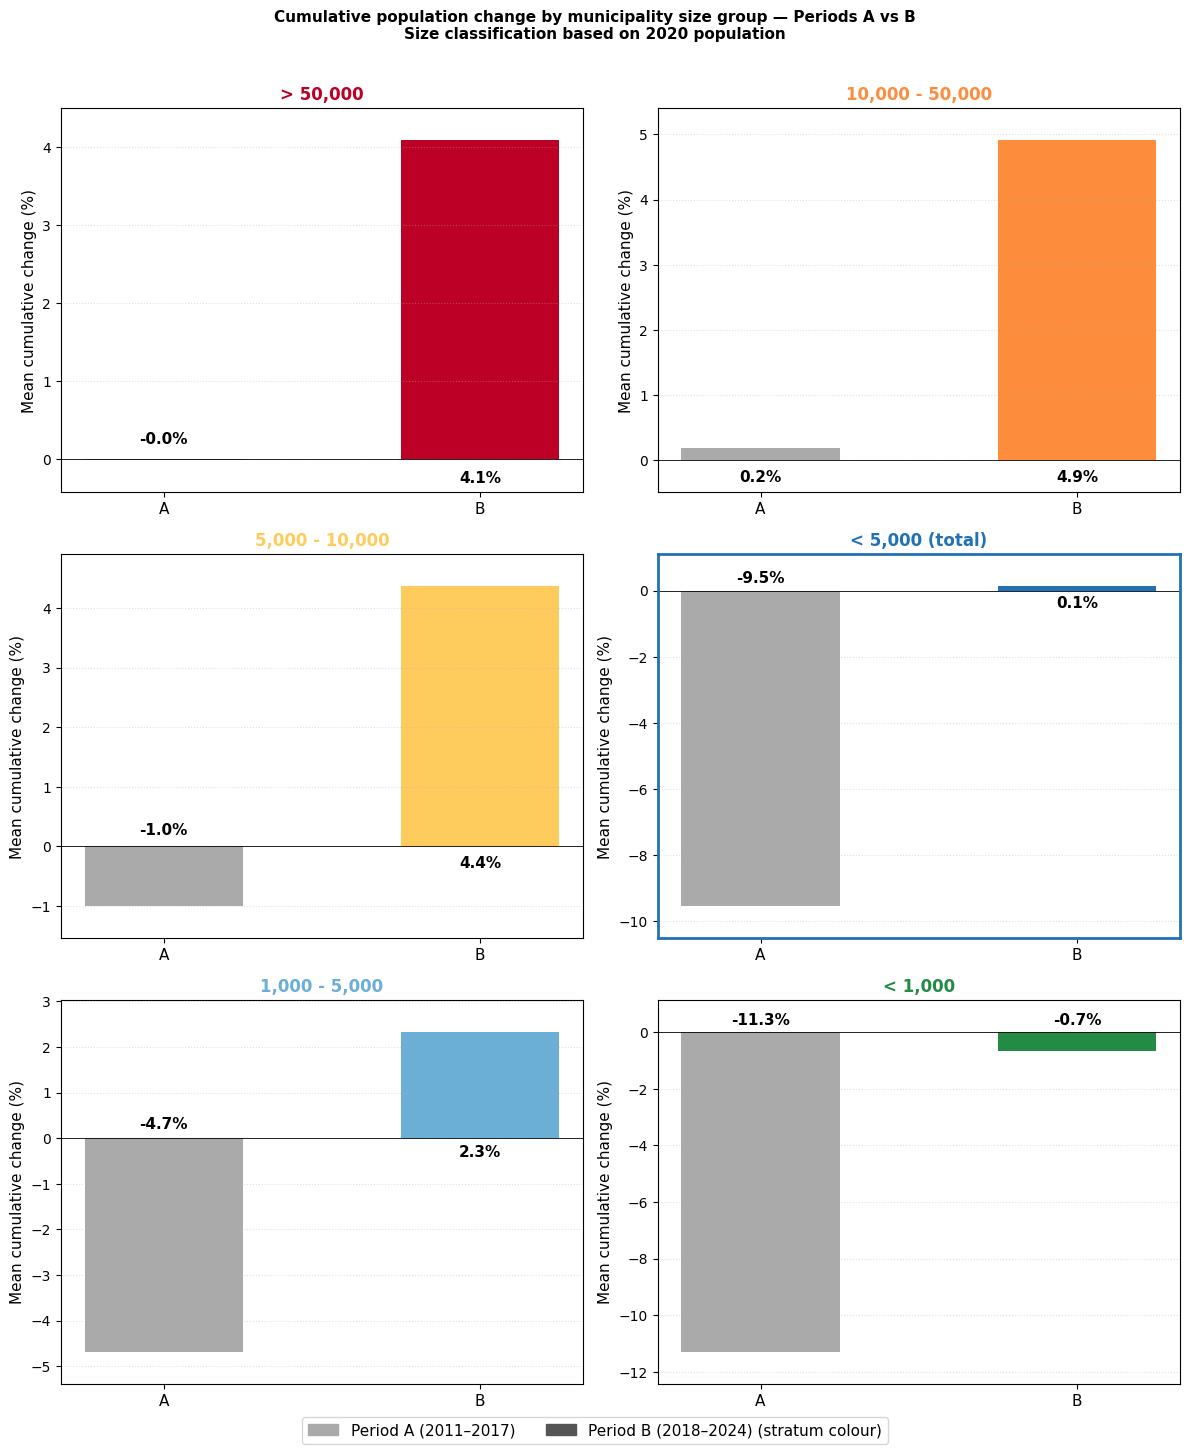

Saved -> p2_fig1_size_combined_en.png
Saved -> p2_fig1_size_pair_top_en.png
Saved -> p2_fig1_size_pair_mid_en.png
Saved -> p2_fig1_size_pair_bot_en.png
Saved -> p2_fig1_size_individual_gt_50000_en.png
Saved -> p2_fig1_size_individual_10000_-_50000_en.png
Saved -> p2_fig1_size_individual_5000_-_10000_en.png
Saved -> p2_fig1_size_individual_lt_5000_(total)_en.png
Saved -> p2_fig1_size_individual_1000_-_5000_en.png
Saved -> p2_fig1_size_individual_lt_1000_en.png
Saved -> p2_fig1_size_combined_es.png
Saved -> p2_fig1_size_pair_top_es.png
Saved -> p2_fig1_size_pair_mid_es.png
Saved -> p2_fig1_size_pair_bot_es.png
Saved -> p2_fig1_size_individual_gt_50000_es.png
Saved -> p2_fig1_size_individual_10000_-_50000_es.png
Saved -> p2_fig1_size_individual_5000_-_10000_es.png
Saved -> p2_fig1_size_individual_lt_5000_(total)_es.png
Saved -> p2_fig1_size_individual_1000_-_5000_es.png
Saved -> p2_fig1_size_individual_lt_1000_es.png

All Figure 1 variants saved.


In [16]:
SIZE_LABELS = {
    'en': {
        'ylabel'   : 'Mean cumulative change (%)',
        'period_a' : 'Period A (2011–2017)',
        'period_b' : 'Period B (2018–2024)',
        'ref_note' : 'Size classification based on 2020 population',
        'suptitle' : 'Cumulative population change by municipality size group — Periods A vs B',
    },
    'es': {
        'ylabel'   : 'Variación acumulada media (%)',
        'period_a' : 'Período A (2011–2017)',
        'period_b' : 'Período B (2018–2024)',
        'ref_note' : 'Clasificación por tamaño basada en población de 2020',
        'suptitle' : 'Variación acumulada de población por grupo de tamaño — Períodos A vs B',
    },
}

SIZE_TITLES_ES = {
    '> 50,000'        : '> 50.000',
    '10,000 - 50,000' : '10.000 - 50.000',
    '5,000 - 10,000'  : '5.000 - 10.000',
    '< 5,000 (total)' : '< 5.000 (total)',
    '1,000 - 5,000'   : '1.000 - 5.000',
    '< 1,000'         : '< 1.000',
}


def draw_size_ab_panel(ax, grp, lang, labels):
    row = agg_sz[agg_sz['group'] == grp]
    if row.empty:
        ax.set_visible(False)
        return
    val_a = row['var_acum_A'].values[0]
    val_b = row['var_acum_B'].values[0]
    color = SIZE_COLORS[grp]

    bars = ax.bar([0, 1], [val_a, val_b],
                  color=[COL_PERIOD_A, color],
                  edgecolor='none', width=0.5)
    ax.axhline(0, color='black', linewidth=0.6)

    # Labels anchored to y=0, inside the bar
    for bar, val in zip(bars, [val_a, val_b]):
        if val >= 0:
            ypos = 0 - 0.15
            va   = 'top'
        else:
            ypos = 0 + 0.15
            va   = 'bottom'
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:.1f}%', ha='center', va=va, fontsize=11, fontweight='bold')

    # Extend y-axis by 10% on both ends to avoid label/tick overlap
    ymin = min(val_a, val_b, 0)
    ymax = max(val_a, val_b, 0)
    yrange = max(ymax - ymin, 1)
    ax.set_ylim(ymin - yrange * 0.10, ymax + yrange * 0.10)

    panel_title = SIZE_TITLES_ES[grp] if lang == 'es' else grp
    if grp == '< 5,000 (total)':
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_edgecolor(color)
    ax.set_title(panel_title, fontsize=12, fontweight='bold', color=color)
    ax.set_ylabel(labels['ylabel'], fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['A', 'B'], fontsize=11)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.tick_params(axis='y', labelsize=10)


for lang, labels in SIZE_LABELS.items():
    show_combined = (lang == 'en')

    # ---- A) Combined 3x2 --------------------------------------------
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    for i, grp in enumerate(SIZE_ORDER):
        draw_size_ab_panel(axes.flatten()[i], grp, lang, labels)
    fig.legend(
        handles=[
            mpatches.Patch(color=COL_PERIOD_A, label=labels['period_a']),
            mpatches.Patch(color='#555555',    label=labels['period_b'] + ' (stratum colour)'),
        ],
        loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02)
    )
    fig.suptitle(f"{labels['suptitle']}\n{labels['ref_note']}",
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    fp = FIGURES_DIR / f'p2_fig1_size_combined_{lang}.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    if show_combined:
        plt.show()
    else:
        plt.close()
    print(f'Saved -> {fp.name}')

    # ---- B) Pairs ---------------------------------------------------
    for pair_idx, pair_name in enumerate(['top', 'mid', 'bot']):
        grp_a = SIZE_ORDER[pair_idx * 2]
        grp_b = SIZE_ORDER[pair_idx * 2 + 1]
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        draw_size_ab_panel(axes[0], grp_a, lang, labels)
        draw_size_ab_panel(axes[1], grp_b, lang, labels)
        fig.suptitle(f"{labels['suptitle']}\n{labels['ref_note']}",
                     fontsize=11, fontweight='bold', y=1.02)
        plt.tight_layout()
        fp = FIGURES_DIR / f'p2_fig1_size_pair_{pair_name}_{lang}.png'
        plt.savefig(fp, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved -> {fp.name}')

    # ---- C) Individual ----------------------------------------------
    for grp in SIZE_ORDER:
        fig, ax = plt.subplots(figsize=(6, 5))
        draw_size_ab_panel(ax, grp, lang, labels)
        fig.suptitle(f"{labels['suptitle']}\n{labels['ref_note']}",
                     fontsize=10, fontweight='bold', y=1.02)
        plt.tight_layout()
        slug = grp.replace(',', '').replace(' ', '_').replace('>', 'gt').replace('<', 'lt')
        fp = FIGURES_DIR / f'p2_fig1_size_individual_{slug}_{lang}.png'
        plt.savefig(fp, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved -> {fp.name}')

print('\nAll Figure 1 variants saved.')

---
## 6 · Figure 2 — Cumulative change by Goerlich typology (Period A vs B)

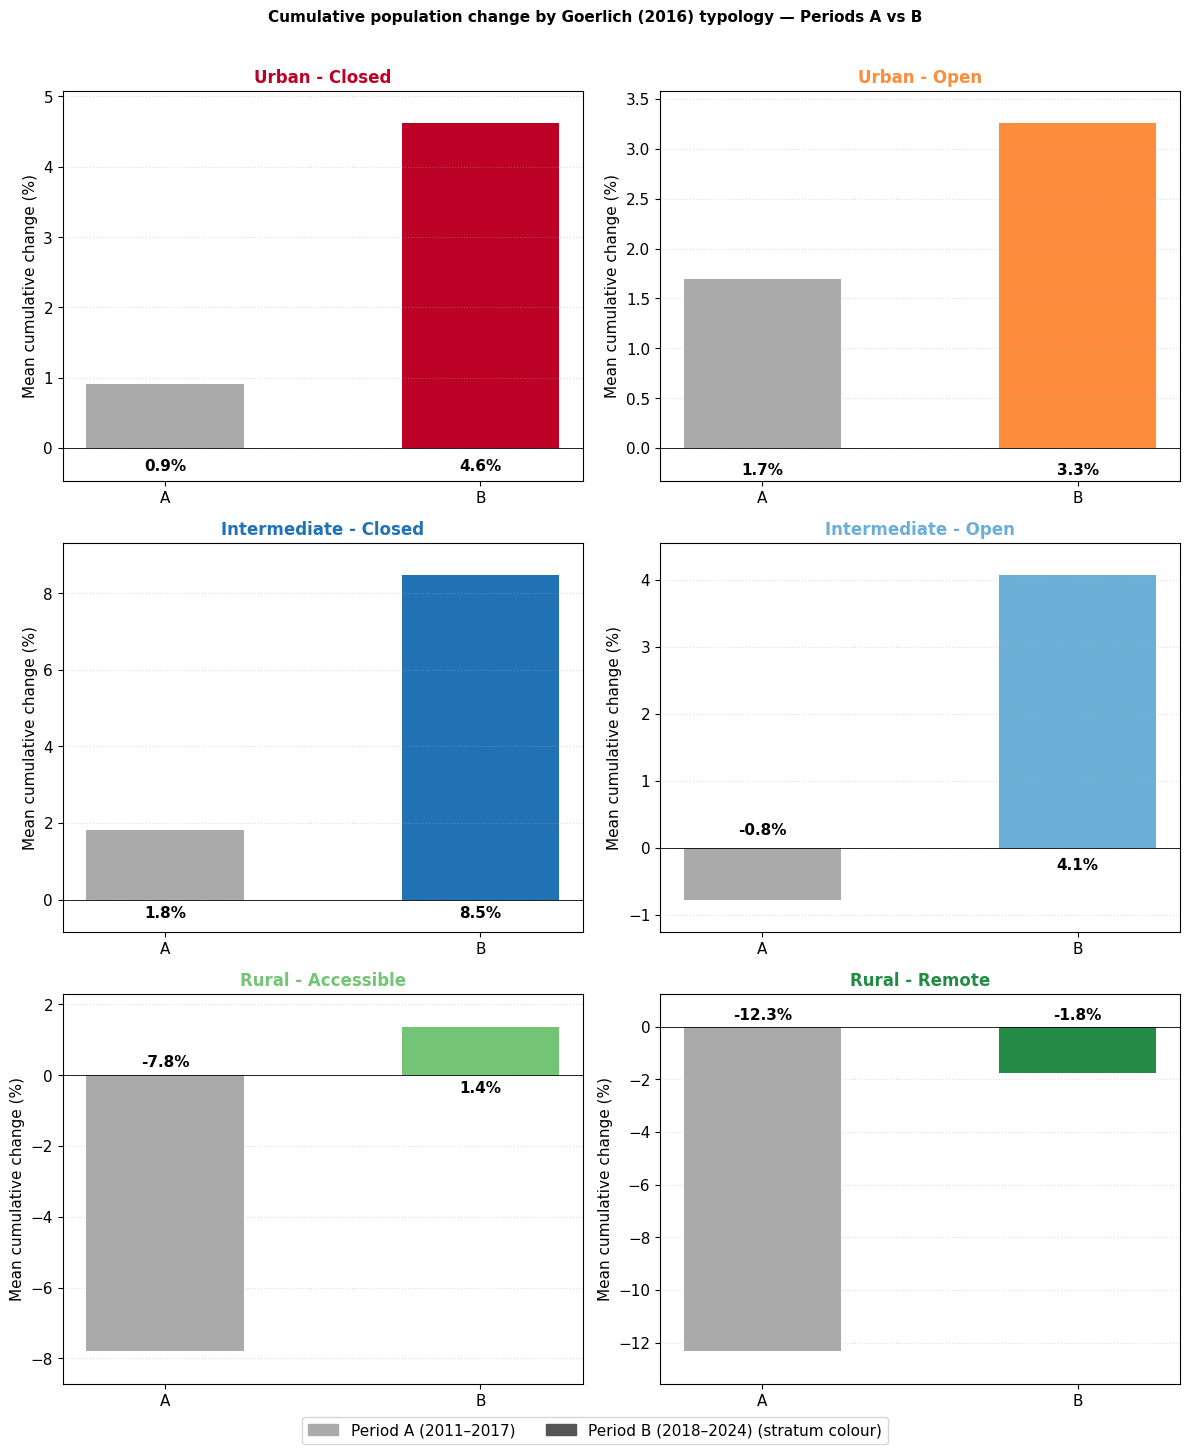

Saved -> p2_fig2_typology_combined_en.png
Saved -> p2_fig2_typology_pair_top_en.png
Saved -> p2_fig2_typology_pair_mid_en.png
Saved -> p2_fig2_typology_pair_bot_en.png
Saved -> p2_fig2_typology_individual_Urbano_Cerrado_en.png
Saved -> p2_fig2_typology_individual_Urbano_Abierto_en.png
Saved -> p2_fig2_typology_individual_Intermedio_Cerrado_en.png
Saved -> p2_fig2_typology_individual_Intermedio_Abierto_en.png
Saved -> p2_fig2_typology_individual_Rural_Accesible_en.png
Saved -> p2_fig2_typology_individual_Rural_Remoto_en.png
Saved -> p2_fig2_typology_combined_es.png
Saved -> p2_fig2_typology_pair_top_es.png
Saved -> p2_fig2_typology_pair_mid_es.png
Saved -> p2_fig2_typology_pair_bot_es.png
Saved -> p2_fig2_typology_individual_Urbano_Cerrado_es.png
Saved -> p2_fig2_typology_individual_Urbano_Abierto_es.png
Saved -> p2_fig2_typology_individual_Intermedio_Cerrado_es.png
Saved -> p2_fig2_typology_individual_Intermedio_Abierto_es.png
Saved -> p2_fig2_typology_individual_Rural_Accesible_es.png

In [18]:
TYPOLOGY_LABELS = {
    'en': {
        'ylabel'   : 'Mean cumulative change (%)',
        'period_a' : 'Period A (2011–2017)',
        'period_b' : 'Period B (2018–2024)',
        'suptitle' : 'Cumulative population change by Goerlich (2016) typology — Periods A vs B',
    },
    'es': {
        'ylabel'   : 'Variación acumulada media (%)',
        'period_a' : 'Período A (2011–2017)',
        'period_b' : 'Período B (2018–2024)',
        'suptitle' : 'Variación acumulada de población por tipología Goerlich (2016) — Períodos A vs B',
    },
}

TYPOLOGY_TITLES_ES = {
    'Urbano - Cerrado'     : 'Urbano - Cerrado',
    'Urbano - Abierto'     : 'Urbano - Abierto',
    'Intermedio - Cerrado' : 'Intermedio - Cerrado',
    'Intermedio - Abierto' : 'Intermedio - Abierto',
    'Rural - Accesible'    : 'Rural - Accesible',
    'Rural - Remoto'       : 'Rural - Remoto',
}

TYPOLOGY_TITLES_EN = {
    'Urbano - Cerrado'     : 'Urban - Closed',
    'Urbano - Abierto'     : 'Urban - Open',
    'Intermedio - Cerrado' : 'Intermediate - Closed',
    'Intermedio - Abierto' : 'Intermediate - Open',
    'Rural - Accesible'    : 'Rural - Accessible',
    'Rural - Remoto'       : 'Rural - Remote',
}


def draw_typology_ab_panel(ax, typ, lang, labels):
    row = agg_typ[agg_typ['tipo_goerlich'] == typ]
    if row.empty:
        ax.set_visible(False)
        return
    val_a = row['var_acum_A'].values[0]
    val_b = row['var_acum_B'].values[0]
    color = GOERLICH_COLORS[typ]

    bars = ax.bar([0, 1], [val_a, val_b],
                  color=[COL_PERIOD_A, color],
                  edgecolor='none', width=0.5)
    ax.axhline(0, color='black', linewidth=0.6)

    for bar, val in zip(bars, [val_a, val_b]):
        if val >= 0:
            ypos = 0 - 0.15
            va   = 'top'
        else:
            ypos = 0 + 0.15
            va   = 'bottom'
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:.1f}%', ha='center', va=va, fontsize=11, fontweight='bold')

    ymin = min(val_a, val_b, 0)
    ymax = max(val_a, val_b, 0)
    yrange = max(ymax - ymin, 1)
    ax.set_ylim(ymin - yrange * 0.10, ymax + yrange * 0.10)

    panel_title = TYPOLOGY_TITLES_EN[typ] if lang == 'en' else TYPOLOGY_TITLES_ES[typ]
    ax.set_title(panel_title, fontsize=12, fontweight='bold', color=color)
    ax.set_ylabel(labels['ylabel'], fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['A', 'B'], fontsize=11)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.tick_params(axis='y', labelsize=11)


for lang, labels in TYPOLOGY_LABELS.items():
    show_combined = (lang == 'en')

    # ---- A) Combined 3x2 --------------------------------------------
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    for i, typ in enumerate(TYPOLOGY_ORDER):
        draw_typology_ab_panel(axes.flatten()[i], typ, lang, labels)
    fig.legend(
        handles=[
            mpatches.Patch(color=COL_PERIOD_A, label=labels['period_a']),
            mpatches.Patch(color='#555555',    label=labels['period_b'] + ' (stratum colour)'),
        ],
        loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02)
    )
    fig.suptitle(labels['suptitle'], fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    fp = FIGURES_DIR / f'p2_fig2_typology_combined_{lang}.png'
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    if show_combined:
        plt.show()
    else:
        plt.close()
    print(f'Saved -> {fp.name}')

    # ---- B) Pairs ---------------------------------------------------
    for pair_idx, pair_name in enumerate(['top', 'mid', 'bot']):
        typ_a = TYPOLOGY_ORDER[pair_idx * 2]
        typ_b = TYPOLOGY_ORDER[pair_idx * 2 + 1]
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        draw_typology_ab_panel(axes[0], typ_a, lang, labels)
        draw_typology_ab_panel(axes[1], typ_b, lang, labels)
        fig.suptitle(labels['suptitle'], fontsize=11, fontweight='bold', y=1.02)
        plt.tight_layout()
        fp = FIGURES_DIR / f'p2_fig2_typology_pair_{pair_name}_{lang}.png'
        plt.savefig(fp, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved -> {fp.name}')

    # ---- C) Individual ----------------------------------------------
    for typ in TYPOLOGY_ORDER:
        fig, ax = plt.subplots(figsize=(6, 5))
        draw_typology_ab_panel(ax, typ, lang, labels)
        fig.suptitle(labels['suptitle'], fontsize=10, fontweight='bold', y=1.02)
        plt.tight_layout()
        slug = typ.replace(' ', '_').replace('-', '').replace('__', '_')
        fp = FIGURES_DIR / f'p2_fig2_typology_individual_{slug}_{lang}.png'
        plt.savefig(fp, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved -> {fp.name}')

print('\nAll Figure 2 variants saved.')

---
## 7 · Export CSVs

In [15]:
out_A = DEMO_DERIV / 'p2_period_A_2011_2017.csv'
out_B = DEMO_DERIV / 'p2_period_B_2018_2024.csv'

df_A.to_csv(out_A, sep=';', encoding='utf-8-sig', index=False)
df_B.to_csv(out_B, sep=';', encoding='utf-8-sig', index=False)

def add_suffix(df, suffix,
               skip=('Mun_Code', 'Mun', 'tipo_goerlich', 'size_group', 'Pop_ref')):
    return df.rename(columns={c: f'{c}_{suffix}' for c in df.columns if c not in skip})

df_combined = add_suffix(df_A, 'A').merge(
    add_suffix(df_B, 'B'),
    on=['Mun_Code', 'Mun', 'tipo_goerlich', 'size_group', 'Pop_ref'],
    how='outer'
)

out_combined = DEMO_DERIV / 'p2_periods_AB_combined.csv'
df_combined.to_csv(out_combined, sep=';', encoding='utf-8-sig', index=False)

print(f'Exported: {out_A.name}        ({len(df_A):,} rows)')
print(f'Exported: {out_B.name}        ({len(df_B):,} rows)')
print(f'Exported: {out_combined.name} ({len(df_combined):,} rows, {len(df_combined.columns)} cols)')

Exported: p2_period_A_2011_2017.csv        (8,132 rows)
Exported: p2_period_B_2018_2024.csv        (8,132 rows)
Exported: p2_periods_AB_combined.csv (8,132 rows, 33 cols)


## 8· Spatial export and administrative aggregation

In [16]:
# =============================================================================
# 8 · Spatial export and administrative aggregation
# =============================================================================

import geopandas as gpd

SPATIAL_DERIVED = BASE_DIR / 'data' / 'spatial' / 'derived'
SPATIAL_PROC    = BASE_DIR / 'data' / 'spatial' / 'processed'
GPKG_IN         = SPATIAL_DERIVED / 'mun_geographic_administrative_hierarchy.gpkg'
GPKG_OUT        = SPATIAL_PROC    / 'p2_periods_AB.gpkg'

# --- Load geometry ---------------------------------------------------
gdf_mun = gpd.read_file(GPKG_IN)
gdf_mun['Mun_Code'] = gdf_mun['Mun_Code'].astype(str).str.zfill(5)
print(f'Geometry loaded: {len(gdf_mun):,} municipalities')
print(f'Columns: {list(gdf_mun.columns)}')

Geometry loaded: 8,132 municipalities
Columns: ['Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name', 'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name', 'NATCODE', 'geometry']


In [17]:
# --- Merge period indicators with geometry ---------------------------
def make_geo_layer(df_period, gdf_mun):
    return gdf_mun.merge(
        df_period[['Mun_Code', 'tipo_goerlich', 'size_group', 'Pop_ref',
                   'pop_start', 'pop_end', 'var_acum_pct', 'var_anual_media_pct']],
        on='Mun_Code', how='left'
    )

gdf_A = make_geo_layer(df_A, gdf_mun)
gdf_B = make_geo_layer(df_B, gdf_mun)

print(f'Layer A: {len(gdf_A):,} features, NaN var_acum_pct: {gdf_A["var_acum_pct"].isna().sum()}')
print(f'Layer B: {len(gdf_B):,} features, NaN var_acum_pct: {gdf_B["var_acum_pct"].isna().sum()}')

Layer A: 8,132 features, NaN var_acum_pct: 18
Layer B: 8,132 features, NaN var_acum_pct: 8


In [18]:
# --- Export GeoPackage (two layers) ----------------------------------
gdf_A.to_file(GPKG_OUT, layer='period_A_2011_2017', driver='GPKG')
gdf_B.to_file(GPKG_OUT, layer='period_B_2018_2024', driver='GPKG')

print(f'GeoPackage exported -> {GPKG_OUT}')
print(f'  Layer: period_A_2011_2017')
print(f'  Layer: period_B_2018_2024')

GeoPackage exported -> C:\Users\juanz\OneDrive\Desktop\UCM\RURIM ESCAPE\GeoSpatial\01_Python Data Analysis\rural-migration-land-use-spain\data\spatial\processed\p2_periods_AB.gpkg
  Layer: period_A_2011_2017
  Layer: period_B_2018_2024


In [19]:
# --- Administrative aggregation: var_acum_pct by admin level ---------
# Levels: CCAA, Provincia, Comarca (if available)
# Metric: mean and median var_acum_pct, n municipalities

ADMIN_LEVELS = {
    'CCAA'    : ['CCAA_Code',    'CCAA_Name'],
    'Prov'    : ['CCAA_Code',    'CCAA_Name',    'Prov_Code',    'Prov_Name'],
    'Comarca' : ['Prov_Code',    'Prov_Name',    'Comarca_Code', 'Comarca_Name'],
}

admin_stats = {}

for level_name, level_cols in ADMIN_LEVELS.items():
    # Check columns exist in gdf_A
    available = [c for c in level_cols if c in gdf_A.columns]
    if len(available) < 2:
        print(f'Skipping {level_name} — columns not found in geometry')
        continue

    rows = []
    for period_label, gdf_p in [('A', gdf_A), ('B', gdf_B)]:
        agg = (
            gdf_p.groupby(available)['var_acum_pct']
            .agg(mean='mean', median='median', n='count')
            .reset_index()
        )
        agg.columns = available + ['var_acum_mean', 'var_acum_median', 'n_mun']
        agg['period'] = period_label
        rows.append(agg)

    df_level = pd.concat(rows, ignore_index=True)
    admin_stats[level_name] = df_level

    # Export CSV
    out_csv = DEMO_DERIV / f'p2_admin_agg_{level_name.lower()}.csv'
    df_level.to_csv(out_csv, sep=';', encoding='utf-8-sig', index=False)
    print(f'Exported: {out_csv.name}')

Exported: p2_admin_agg_ccaa.csv
Exported: p2_admin_agg_prov.csv
Exported: p2_admin_agg_comarca.csv


In [20]:
# --- Top/bottom units per level and period ---------------------------
N_EXTREME = 10

for level_name, df_level in admin_stats.items():
    name_col = ADMIN_LEVELS[level_name][-1]  # last column is always the name
    print(f'\n{"="*60}')
    print(f'Level: {level_name}')

    # Extra context columns depending on level
    if level_name == 'Comarca':
        extra_cols = ['Prov_Name'] if 'Prov_Name' in df_level.columns else []
    elif level_name == 'Prov':
        extra_cols = ['CCAA_Name'] if 'CCAA_Name' in df_level.columns else []
    else:
        extra_cols = []

    display_cols = extra_cols + [name_col, 'var_acum_mean', 'var_acum_median', 'n_mun']

    for period_label in ['A', 'B']:
        sub = df_level[df_level['period'] == period_label].copy()
        sub = sub.sort_values('var_acum_mean')

        print(f'\n  --- Period {period_label} ---')
        print(f'  Bottom {N_EXTREME} (strongest depopulation):')
        print(sub.head(N_EXTREME)[display_cols].to_string(index=False))
        print(f'\n  Top {N_EXTREME} (strongest growth):')
        print(sub.tail(N_EXTREME)[display_cols].to_string(index=False))


Level: CCAA

  --- Period A ---
  Bottom 10 (strongest depopulation):
                 CCAA_Name  var_acum_mean  var_acum_median  n_mun
        Castilla-La Mancha     -13.970596       -13.285024    919
                  La Rioja     -11.344263       -10.836689    174
           Castilla y León     -11.234608       -11.752610   2248
                    Aragón     -10.301407       -10.344828    731
                   Galicia      -8.568735        -8.715738    313
    Principado de Asturias      -8.387482        -7.800062     78
      Comunitat Valenciana      -7.421895        -6.217137    542
               Extremadura      -6.647723        -6.382979    385
                 Andalucía      -5.120914        -4.796560    771
Comunidad Foral de Navarra      -4.519449        -4.880887    272

  Top 10 (strongest growth):
                 CCAA_Name  var_acum_mean  var_acum_median  n_mun
Comunidad Foral de Navarra      -4.519449        -4.880887    272
                 Cantabria      -3.957075

---
## 9 · Interpretation notes

**Key findings from this notebook (p2):**

**By Goerlich typology:**
- **Rural - Accesible** shows a full reversal (YES): from −7.8% in A to +1.4% in B,
  confirming that accessible rural municipalities crossed into positive cumulative
  growth after T=2018.
- **Rural - Remoto** shows a strong partial reversal: from −12.3% in A to −1.8% in B
  (delta = +10.6 pp). The shift is the largest of any stratum but does not reach
  positive territory — sustained depopulation continues, now at a much reduced rate.
- **Intermediate and Urban typologies** were already positive or near zero in A and
  accelerated further in B — consistent with a broad demographic recovery rather than
  a purely rural phenomenon, though the magnitude of the shift is largest in rural strata.
- **No typology shows a negative trajectory in B** — the counter-urbanisation hypothesis
  of urban loss is not supported at the mean level. Urban typologies grew faster in B
  than in A (Urbano - Cerrado: +0.9% → +4.6%).

**By size group:**
- **< 1,000 hab.** shows the largest absolute shift (+10.6 pp) but remains negative
  in B (−0.7%): the smallest municipalities are recovering but have not yet stabilised.
- **1,000–5,000 hab.** achieves full reversal (−4.7% → +2.3%), the clearest empirical
  confirmation of the MITERD (2018) inflection at this size threshold.
- **< 5,000 (total)** aggregate: −9.5% → +0.1%, marginal positive — the sign change
  is real but fragile.
- **All groups ≥ 5,000 hab.** show strong growth in B (>4%), driven partly by
  peri-urban dynamics and coastal/metropolitan attraction.

**Geographic concentration (administrative aggregation):**
- Depopulation in A was geographically concentrated in interior Castile
  (Cuenca, Guadalajara, Soria, Ávila, Zamora) and Galicia interior (Ourense).
- In B, the same provinces lead in depopulation but at reduced rates; Zamora,
  Salamanca and León remain the most severe cases.
- Strongest growth in B: Madrid, Illes Balears, Alicante, Girona, Murcia —
  coastal and metropolitan provinces, not rural interior.
- At comarca level, the strongest B growth among nominally rural inland areas
  includes Lozoya-Somosierra and Campiña (both Madrid province) and Campiña
  (Guadalajara) — all within commuting distance of Madrid city. These likely
  reflect peri-urbanisation rather than counter-urbanisation and should be
  treated as a methodological caveat: proximity to metropolitan areas inflates
  rural recovery figures and must be controlled for in Paso 3 spatial outlier
  analysis.

**Methodological note:**
Figures show mean var_acum_pct per stratum — a municipality-level average,
not a population-weighted aggregate. Large municipalities contribute equally
to the mean as small ones. Population-weighted aggregation is deferred to Paso 3.

---
## 10 · Dependencies

```
pandas, numpy, matplotlib
```
All available in the `rural-migration` conda environment. No additional installs required.